# Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

## Load Data

In [1]:
import pandas as pd
from pandas.core.common import random_state

# Load data
df = pd.read_csv(
    'data/reviews.csv',
)

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              18442 non-null  int64
 1   Age                      18442 non-null  int64
 2   Title                    18442 non-null  str  
 3   Review Text              18442 non-null  str  
 4   Positive Feedback Count  18442 non-null  int64
 5   Division Name            18442 non-null  str  
 6   Department Name          18442 non-null  str  
 7   Class Name               18442 non-null  str  
 8   Recommended IND          18442 non-null  int64
dtypes: int64(4), str(5)
memory usage: 1.3 MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [2]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [3]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

# Your Work

## Data Exploration

In [4]:
X_train.describe()

,Clothing ID,Age,Positive Feedback Count
count,16597.000000,16597.000000,16597.000000
mean,954.951618,43.370609,2.713924
std,141.863331,12.216240,6.014332
min,2.000000,18.000000,0.000000
25%,863.000000,34.000000,0.000000
50%,952.000000,42.000000,1.000000
75%,1078.000000,52.000000,3.000000
max,1205.000000,99.000000,122.000000


In [5]:
X_train.shape
X_train.head()

,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
893,1060,37,Super cute. pockets would be nice,Easy and fun jumper. runs slightly large. i or...,2,General Petite,Bottoms,Pants
1767,1072,23,Great for all seasons,The dress looks great both in winter and summe...,0,General Petite,Dresses,Dresses
4491,1078,41,Just ok,I wanted to love this dress as it seemed perfe...,10,General,Dresses,Dresses
17626,862,52,Cute but...,I loved this shirt when i purchased it but it ...,6,General Petite,Tops,Knits
11184,1083,28,Grandmas draperies dress,I had to review this because i purchased befor...,3,General,Dresses,Dresses


C:\Users\mjxc_\PycharmProjects\dsnd-pipelines-project\.venv\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
C:\Users\mjxc_\PycharmProjects\dsnd-pipelines-project\.venv\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
C:\Users\mjxc_\PycharmProjects\dsnd-pipelines-project\.venv\Lib\site-packages\scipy\cluster\hierarchy.py:2950: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([dvw, 0])


<Axes: >

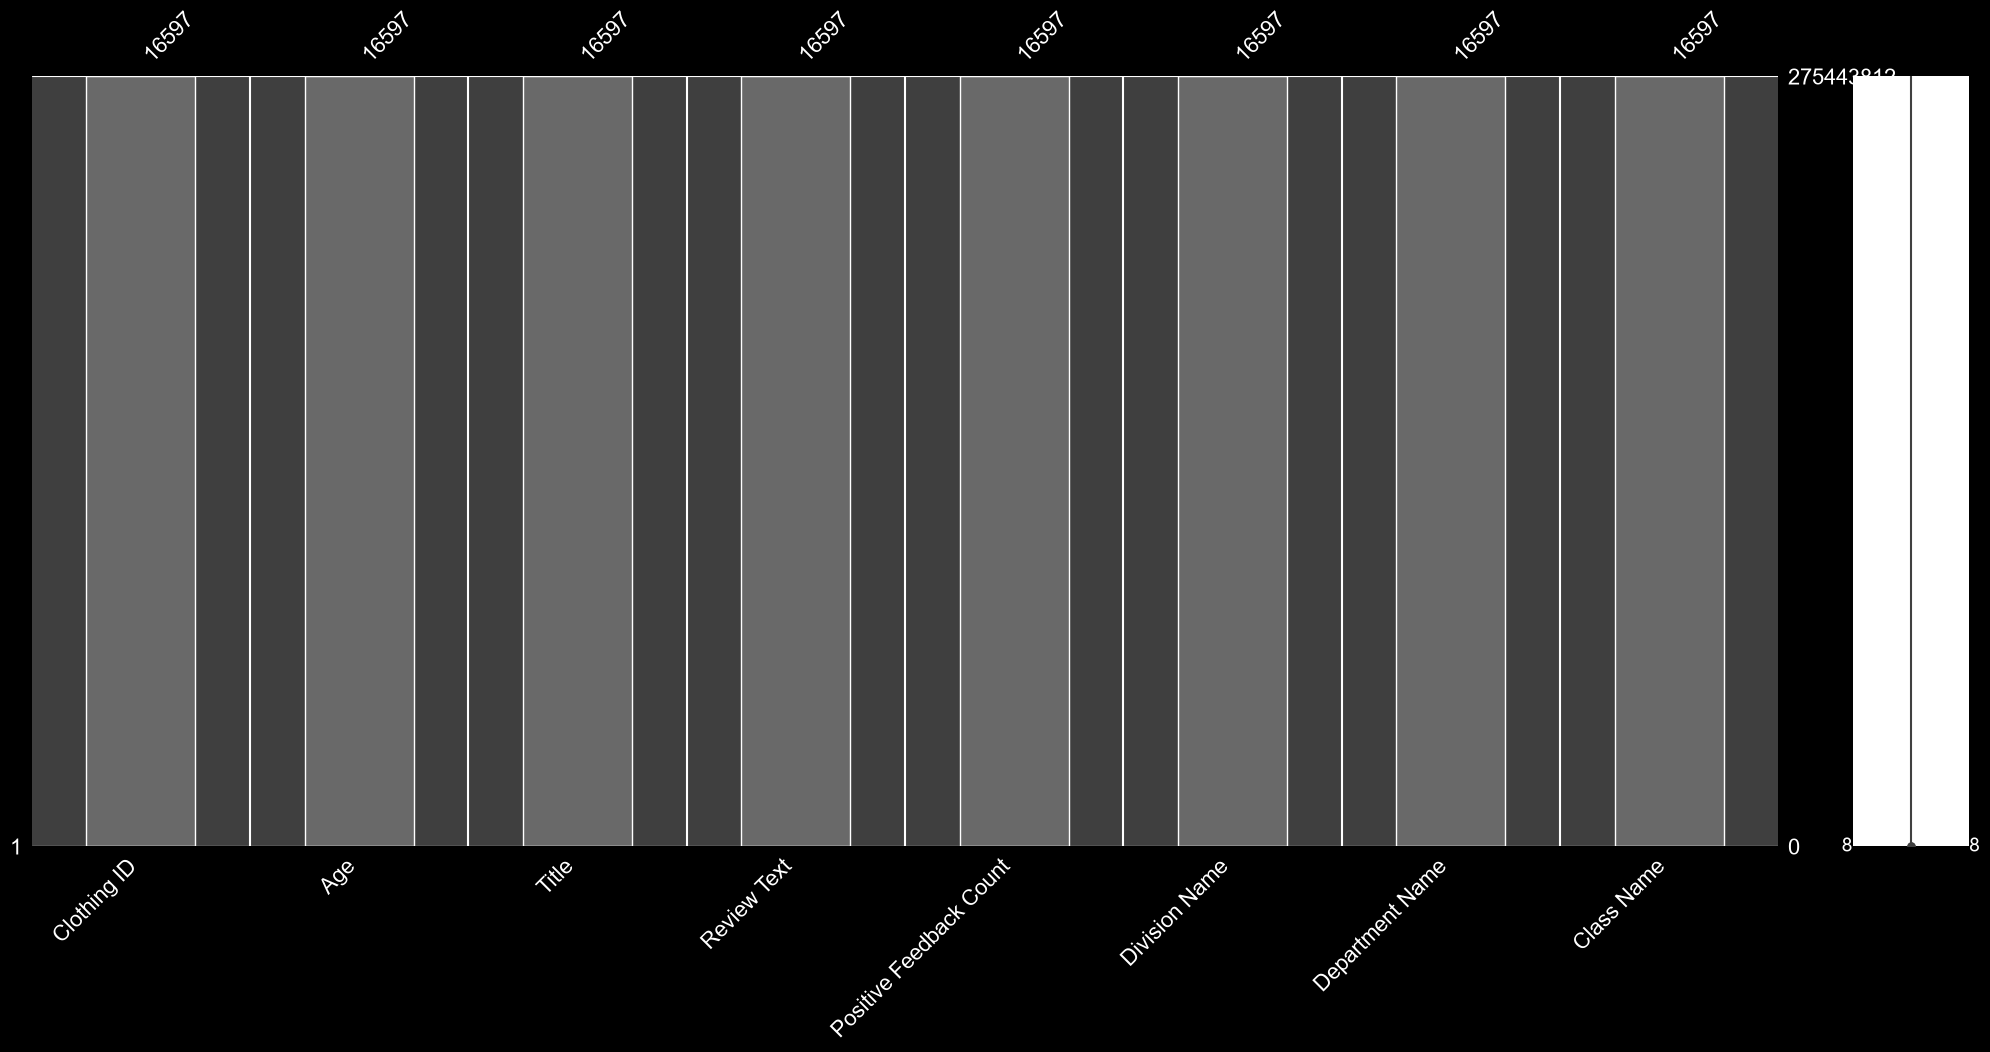

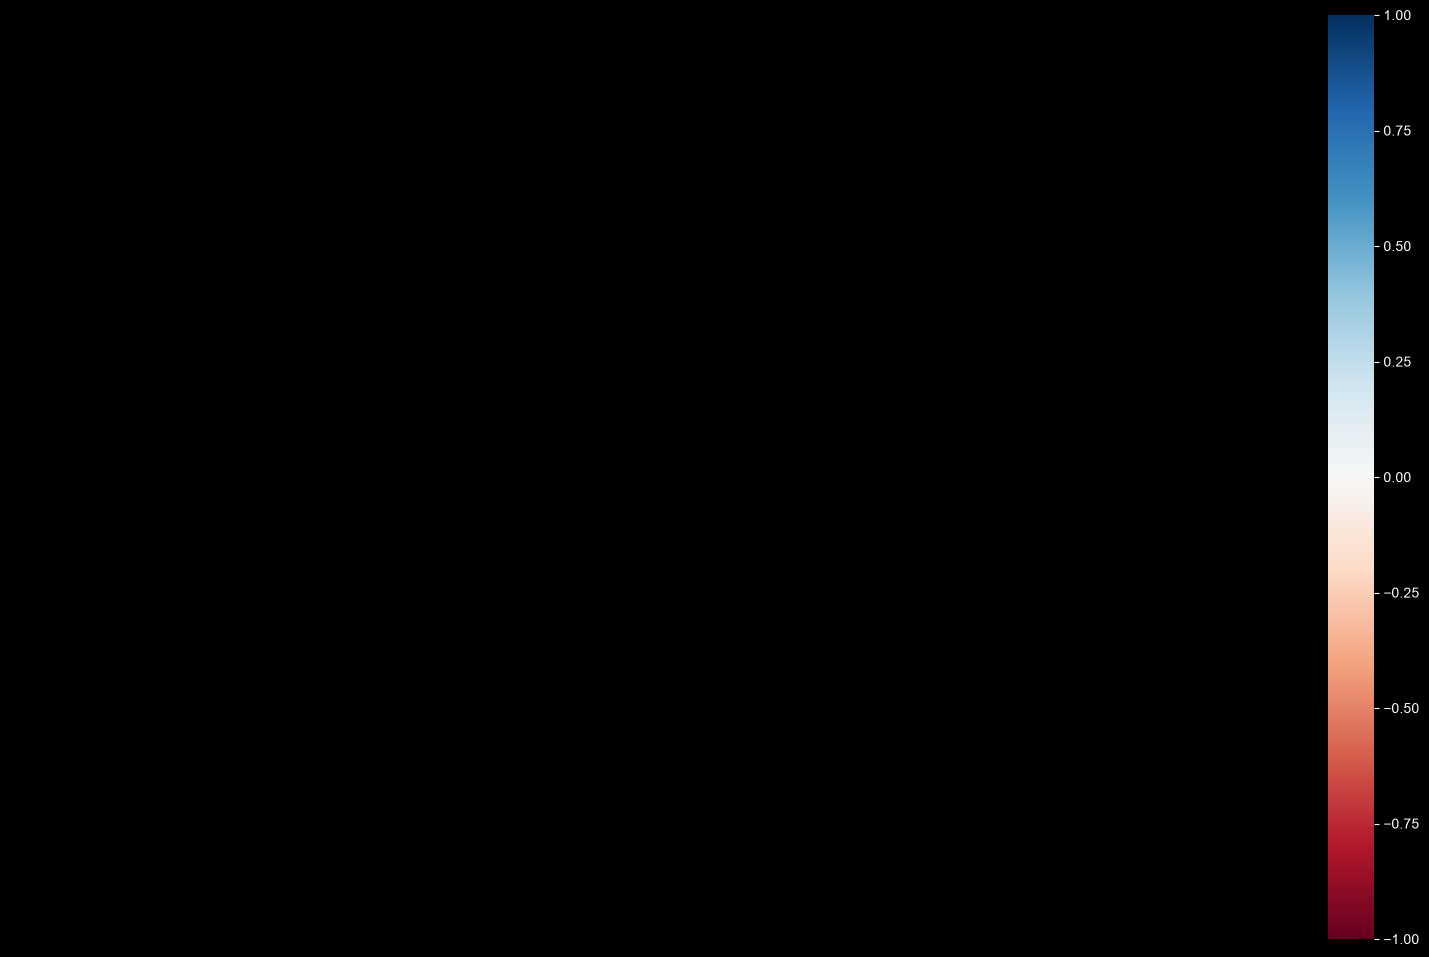

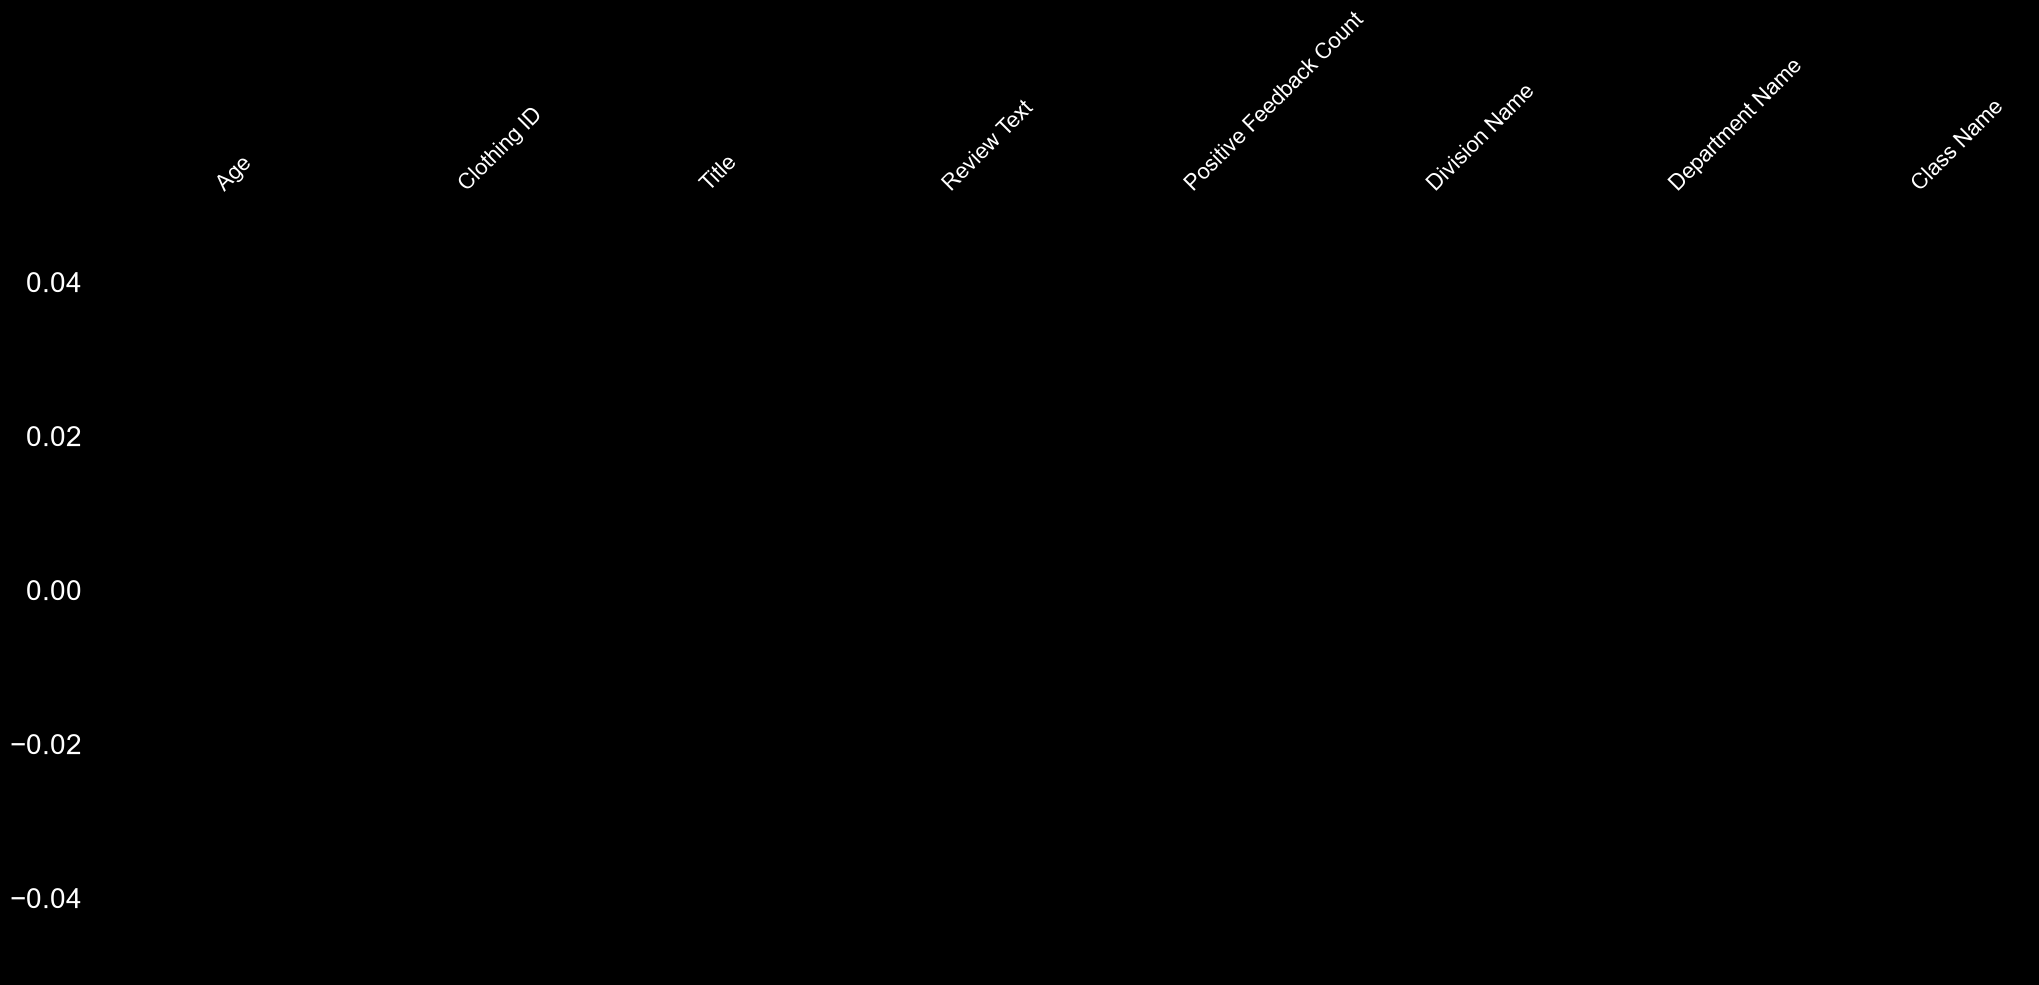

In [6]:
import missingno as msno

msno.matrix(X_train)
msno.bar(X_train)
msno.heatmap(X_train)
msno.dendrogram(X_train)

In [7]:
y_train.value_counts()
y_train.value_counts(normalize=True)

Recommended IND
1    0.815509
0    0.184491
Name: proportion, dtype: float64

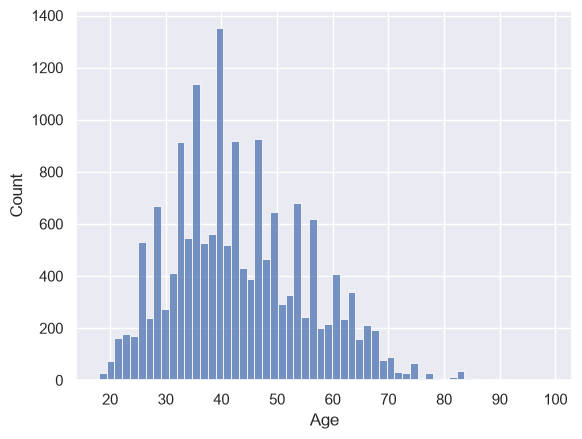

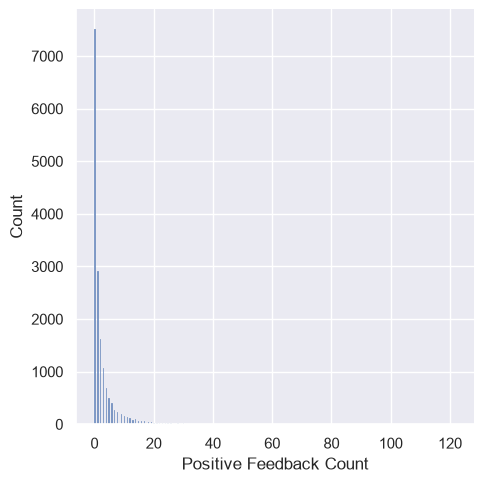

In [8]:
import seaborn as sns

sns.set_theme(style="darkgrid")
sns.histplot(X_train['Age'])
sns.displot(X_train['Positive Feedback Count'])
#sns.catplot(data=X_train, kind="box")

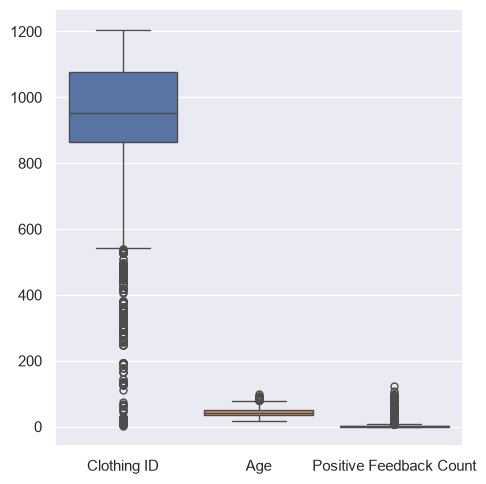

In [9]:
sns.catplot(data=X_train, kind="box")

In [10]:
X_train.columns

display(X_train['Division Name'].unique())
display(X_train['Department Name'].unique())
display(X_train['Class Name'].unique())

<StringArray>
['General Petite', 'General']
Length: 2, dtype: str

<StringArray>
['Bottoms', 'Dresses', 'Tops', 'Jackets', 'Trend', 'Intimate']
Length: 6, dtype: str

<StringArray>
[         'Pants',        'Dresses',          'Knits',     'Fine gauge',
         'Skirts',          'Jeans',        'Blouses',        'Jackets',
         'Shorts',      'Outerwear',       'Sweaters',          'Trend',
         'Lounge', 'Casual bottoms']
Length: 14, dtype: str

In [11]:
#X_train[X_train['Class Name'] == 'Trend'].shape

print(X_train['Department Name'].value_counts())
print(X_train['Class Name'].value_counts())

Department Name
Tops        7818
Dresses     4845
Bottoms     2852
Jackets      813
Intimate     172
Trend         97
Name: count, dtype: int64
Class Name
Dresses           4845
Knits             3554
Blouses           2337
Sweaters          1095
Pants             1041
Jeans              885
Fine gauge         832
Skirts             693
Jackets            549
Outerwear          264
Shorts             232
Lounge             172
Trend               97
Casual bottoms       1
Name: count, dtype: int64


In [12]:
print(X_train.duplicated().sum())

0


In [13]:
X_train.columns

Index(['Clothing ID', 'Age', 'Title', 'Review Text', 'Positive Feedback Count',
       'Division Name', 'Department Name', 'Class Name'],
      dtype='str')

## Building Pipeline

In [14]:
from sklearn.pipeline import Pipeline
import numpy as np

num_features = (
    X_train
    .select_dtypes(exclude=['object']).columns
    .drop(
        [
            'Clothing ID', # More of category than a numerical feature
            'Positive Feedback Count'
        ],
    )
)
print('Numerical features:', num_features)


num_features_log = (
    X_train[[
        'Positive Feedback Count',
        ]].columns
)

print('Log Numerical features:', num_features_log)

cat_features = (
    X_train[[
        'Division Name',
        'Department Name',
        'Class Name',
    ]].columns
)
print('Categorical features:', cat_features)


text_features = (
    X[[
        'Title',
        'Review Text',
    ]].columns
)
print ('Review Text features:', text_features)

Numerical features: Index(['Age'], dtype='str')
Log Numerical features: Index(['Positive Feedback Count'], dtype='str')
Categorical features: Index(['Division Name', 'Department Name', 'Class Name'], dtype='str')
Review Text features: Index(['Title', 'Review Text'], dtype='str')


## Training Pipeline

In [15]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
import spacy, click

nlp = spacy.load('en_core_web_sm')

num_pipeline = Pipeline([
    (
        'scaler',
        StandardScaler(),
    ),
])

log_transformer =  FunctionTransformer(np.log1p, validate=False)

num_pipeline_log = Pipeline([
    (
        'log1p',
        log_transformer,
    ),
    (
        'scaler',
        StandardScaler(),
    ),
])

cat_pipeline = Pipeline([
    (
        'cat_encoder',
        OneHotEncoder(
            sparse_output=False,
            handle_unknown='ignore',)
    ),
])

class Merger(BaseEstimator, TransformerMixin):
    def __init__(self, Col1, Col2):
        self.Col1 = Col1
        self.Col2 = Col2

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        merged = X[self.Col1] + ' ' +X[self.Col2]
        return merged

class SpacyLemmatizer(BaseEstimator, TransformerMixin):
    def __init__(self, nlp):
        self.nlp = nlp

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        lemmatized = [
            ' '.join(
                token.lemma_ for token in doc
                if not token.is_stop
            )
            for doc in self.nlp.pipe(X)
        ]
        return lemmatized


tfidf_pipeline = Pipeline([
    (
       'merger',
        Merger(Col1='Title', Col2='Review Text'),
    ),
    (
       'lemmatizer',
        SpacyLemmatizer(nlp=nlp),
    ),
    (
        'tfidf_vectorizer',
        TfidfVectorizer(
            stop_words='english',
        ),
    ),
])

feature_engineering = ColumnTransformer([
        ('num', num_pipeline, num_features),
        ('num_log', num_pipeline_log, num_features_log),
        ('cat', cat_pipeline, cat_features),
        ('tfidf_text', tfidf_pipeline, text_features),
])

feature_engineering

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('num_log', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

model_pipeline = make_pipeline(
    feature_engineering,
    LogisticRegression(random_state=27, solver='saga'),
)

clf = model_pipeline.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])

## Fine-Tuning Pipeline

In [ ]:
from sklearn.model_selection import GridSearchCV
clf.named_steps

param_grid = {
    'columntransformer__tfidf_text__tfidf_vectorizer__ngram_range': [(1,2), (1,3), (2,2)],
    'logisticregression__penalty': ['l1', 'l2']
    #'columntransformer__tfidf_text__tfidf_vectorizer__max_df': [0.7, 0.9], << removed for speed
    #'columntransformer__tfidf_text__tfidf_vectorizer__min_df': [1, 3], << removed for speed
}


param_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
    verbose=True,
)


param_search.fit(X_train, y_train)

# Retrieve the best parameters
param_search.best_params_

In [ ]:
pd.DataFrame(param_search.cv_results_)

In [19]:
from sklearn.metrics import accuracy_score,  precision_score, recall_score

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test,  y_pred)
rec = recall_score(y_test, y_pred)

print('Accuracy Score: ', acc)
print('Precision Score: ', pre)
print('Recall Score: ', rec)


Accuracy Score:  0.8921409214092141
Precision Score:  0.908359133126935
Recall Score:  0.9664031620553359


In [18]:
from sklearn.metrics import f1_score, classification_report

f1 = f1_score(y_test, clf.predict(X_test), average='weighted')
print('F1 Score:', f1)

print(classification_report(y_test, clf.predict(X_test)))


F1 Score: 0.8844189406857873
              precision    recall  f1-score   support

           0       0.78      0.55      0.64       327
           1       0.91      0.97      0.94      1518

    accuracy                           0.89      1845
   macro avg       0.84      0.76      0.79      1845
weighted avg       0.89      0.89      0.88      1845



In [ ]:
from matplotlib import pyplot as plt
#Evaluation enhanced
from sklearn.metrics import confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, PrecisionRecallDisplay, precision_recall_curve

y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=clf.classes_)

labels = np.array([
    [f'{count}\n({pct:.1%})'
     for count, pct in zip(cm_row, pct_row)]
    for cm_row, pct_row in zip(cm, cm_norm)
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Recommended', 'Recommended']
)

disp.plot(cmap='Blues', values_format='')
# Override the text
for text, label in zip(disp.text_.ravel(), labels.ravel()):
    text.set_text(label)

plt.show()

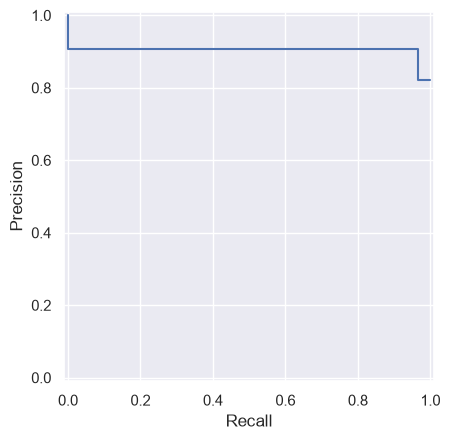

In [26]:
#Precision- recall
from sklearn.metrics import  precision_score, recall_score, precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, predictions)
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()
plt.show()